Кластеризация - Duke


Файл 27_p1_a.txt: всего точек 848
Найдено кластеров: 1
Кластер 1: 848 точек, центр (7.4833, 6.9009)
Px = 7.483270, Py = 6.900943
Целая часть Px*100000 = 748327
Целая часть Py*100000 = 690094


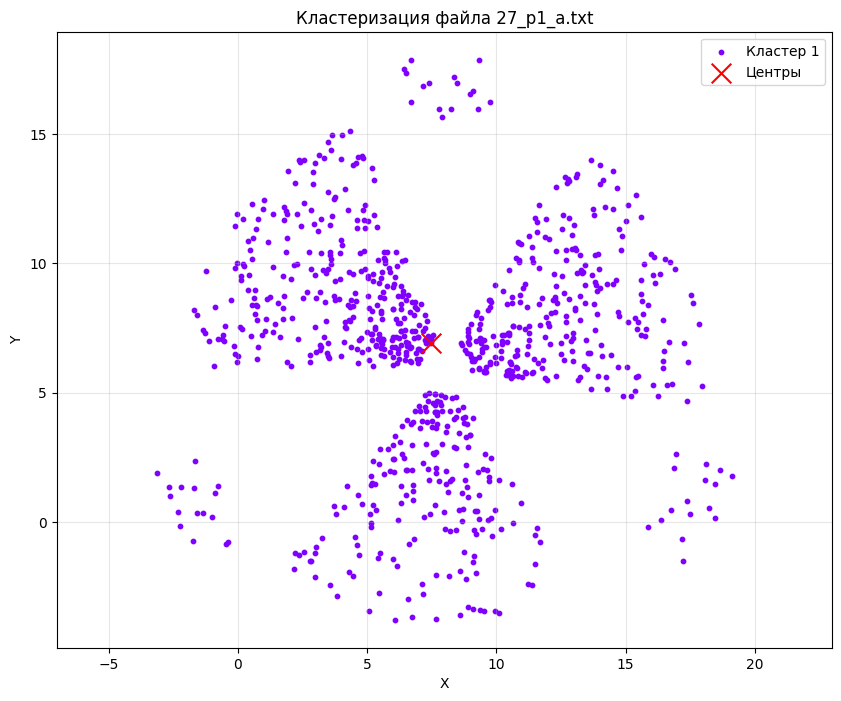

Файл 27_p1_b.txt: всего точек 4566
Найдено кластеров: 1
Кластер 1: 4566 точек, центр (6.9907, 6.0270)
Px = 6.990732, Py = 6.027028
Целая часть Px*100000 = 699073
Целая часть Py*100000 = 602702


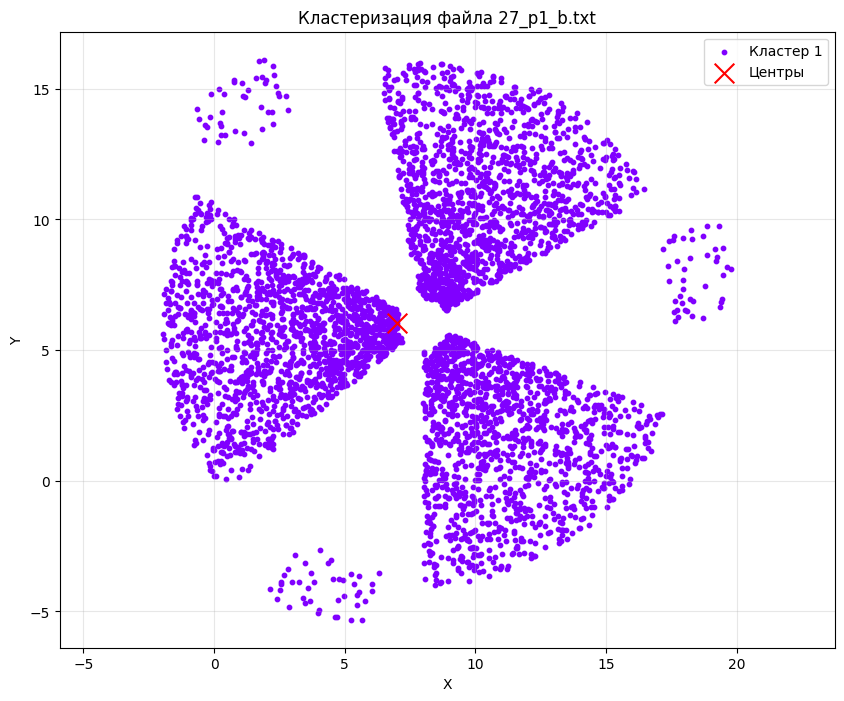

Файл A: 748327 690094
Файл B: 699073 602702


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.cluster import DBSCAN

def read_points(filename):
    points = []
    with open(filename, 'r') as f:
        for line in f:
            if line.strip():
                x, y = map(lambda s: float(s.replace(',', '.')), line.strip().split())
                points.append([x, y])
    return np.array(points)

def find_cluster_center(cluster_points):
    min_sum_dist = float('inf')
    center = None
    
    for i, point in enumerate(cluster_points):
        dist_sum = 0
        for j, other in enumerate(cluster_points):
            if i != j:
                dist = np.sqrt((point[0] - other[0])**2 + (point[1] - other[1])**2)
                dist_sum += dist
        if dist_sum < min_sum_dist:
            min_sum_dist = dist_sum
            center = point
    return center
def cluster_points_dbscan(points, eps=9, min_samples=1):
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_
    unique_labels = set(labels)
    if -1 in unique_labels:
        unique_labels.remove(-1)
    
    clusters = []
    for label in unique_labels:
        cluster = points[labels == label]
        clusters.append(cluster)
    
    return clusters

def analyze_file(filename, R=9, plot=False):
    points = read_points(filename)
    print(f"Файл {filename}: всего точек {len(points)}")
    clusters = cluster_points_dbscan(points, eps=R)
    print(f"Найдено кластеров: {len(clusters)}")
    centers = []
    for i, cluster in enumerate(clusters):
        center = find_cluster_center(cluster)
        centers.append(center)
        print(f"Кластер {i+1}: {len(cluster)} точек, центр ({center[0]:.4f}, {center[1]:.4f})")
    centers = np.array(centers)
    Px = np.mean(centers[:, 0])
    Py = np.mean(centers[:, 1])
    print(f"Px = {Px:.6f}, Py = {Py:.6f}")
    print(f"Целая часть Px*100000 = {int(Px * 100000)}")
    print(f"Целая часть Py*100000 = {int(Py * 100000)}")
    
    if plot:
        plt.figure(figsize=(10, 8))
        colors = plt.cm.rainbow(np.linspace(0, 1, len(clusters)))
        for i, (cluster, color) in enumerate(zip(clusters, colors)):
            plt.scatter(cluster[:, 0], cluster[:, 1], c=[color], label=f'Кластер {i+1}', s=10)
        
        centers = np.array(centers)
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, label='Центры')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title(f'Кластеризация файла {filename}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.show()
    return centers, Px, Py
centers_A, Px_A, Py_A = analyze_file('27_p1_a.txt', R=9, plot=True)
centers_B, Px_B, Py_B = analyze_file('27_p1_b.txt', R=9, plot=True)

print(f"Файл A: {int(Px_A * 100000)} {int(Py_A * 100000)}")
print(f"Файл B: {int(Px_B * 100000)} {int(Py_B * 100000)}")

сложна, а еще я не понял куда деть файл b2, по этому сделал с 2умя